In [66]:
import matplotlib as mpl
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from photutils.aperture import CircularAnnulus, CircularAperture
from photutils.aperture import ApertureStats
import scipy.ndimage as ndimage


def sky_temp(T_atm, tau_atm, airmass):
    return T_atm * (1-np.exp(-tau_atm*airmass))

def fit_skydip(tod, T_skydip):
        pars = np.polyfit(T_skydip, tod, 1)
        model = np.poly1d(pars)
        resp = pars[0]

        return resp

In [67]:
filename = '/Users/eleonora/Desktop/SRT-marzo/20250331-234226-MISTRAL-GAIN_CAL/20250331-234226-MISTRAL-GAIN_CAL_005_001.fits'
hdul = fits.open(filename) 

T_atm = 267 #K
tau_atm = 0.15

hdul.info()

Filename: /Users/eleonora/Desktop/SRT-marzo/20250331-234226-MISTRAL-GAIN_CAL/20250331-234226-MISTRAL-GAIN_CAL_005_001.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      76   ()      
  1  SECTION TABLE    1 BinTableHDU     30   2R x 7C   [J, 8A, D, J, D, D, D]   
  2  RF INPUTS     1 BinTableHDU     33   2R x 9C   [J, J, 8A, D, D, D, D, D, J]   
  3  FEED TABLE    1 BinTableHDU     33   355R x 10C   [J, D, D, D, J, 2D, D, D, D, D]   
  4  DATA TABLE    1 BinTableHDU     35   6870R x 10C   [D, D, D, D, D, D, J, 3D, 1E, 1E]   
  5  IQ TABLE      1 BinTableHDU   1429   6870R x 710C   [J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J

355


/var/folders/sw/rx6w9htn5cqgk3lgfmcmjdtc0000gn/T/ipykernel_20983/4187731109.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap('jet', nchan)


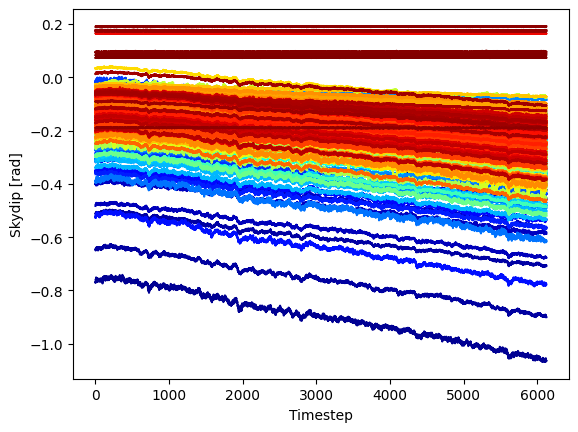

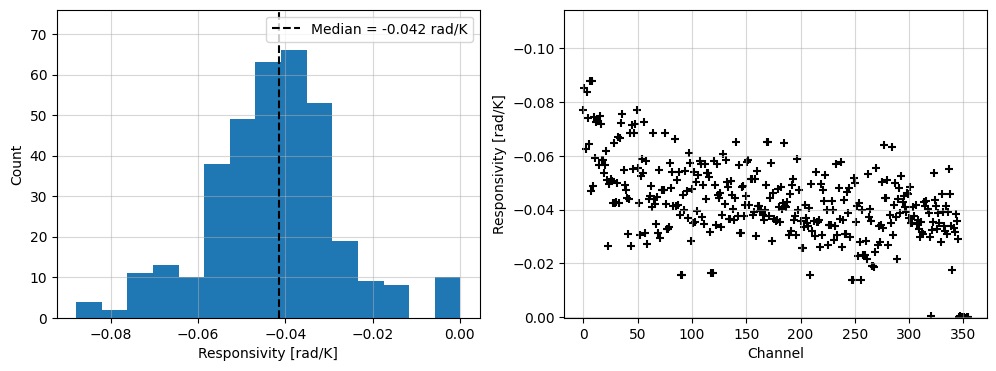

In [68]:
dt = hdul["DATA TABLE"].data
pt = hdul["PH TABLE"].data

nchan = len(pt[0])

mask = dt["flag_track"].astype(bool)

el_rad = dt["el"][mask]
z = np.pi/2 - el_rad
airmass = 1 / np.cos(z)

T_skydip = sky_temp(T_atm, tau_atm, airmass)

resps = []

channels = np.arange(nchan)
skydips = []
resps = []

print(nchan)
for i in channels:
    tod = pt["chp_"+str(i).zfill(3)][mask]
    skydips.append(tod)
    resp = fit_skydip(tod, T_skydip)
    resps.append(resp)
    
resps = np.array(resps)        
med_resp = np.median(resps)
resps_norm = np.array(resps) / med_resp  


fig, ax = plt.subplots(dpi=100)
cmap = mpl.cm.get_cmap('jet', nchan)
sm = plt.cm.ScalarMappable(cmap=cmap)
for i in range(nchan):
    if i == 0:
        im =ax.plot(skydips[i], c=cmap(i))
    else:
        ax.plot(skydips[i], c=cmap(i))
ax.set_xlabel("Timestep")
ax.set_ylabel("Skydip [rad]")
plt.show()

fig, (ax1,ax2) = plt.subplots(ncols=2, nrows=1, figsize=(12,4))  
hst = ax1.hist(resps,bins=15)
#ax1.set_title("SKYDIP")
ax1.set_xlabel("Responsivity [rad/K]")
ax1.set_ylabel("Count")
ax1.vlines(med_resp, ymin=min(hst[0]), ymax=max(hst[0])+10, color="k", ls="dashed", label="Median = "+str(round(med_resp,3))+" rad/K")
ax1.set_ylim(0,max(hst[0])+10)
ax1.legend()
ax1.grid(alpha=0.5)

ax2.scatter(channels, resps, color="k", marker="+")
ax2.set_ylim(max(resps)*1.3, min(resps)*1.3)
ax2.set_xlabel("Channel")
ax2.set_ylabel("Responsivity [rad/K]")
ax2.grid(alpha=0.5)


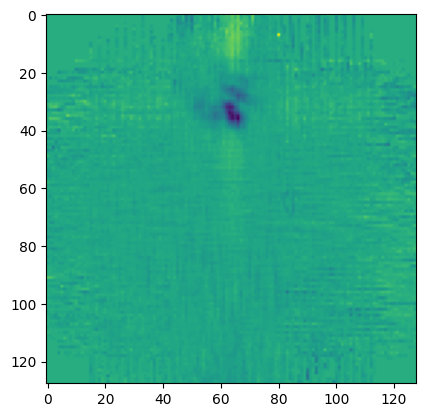

Name file:  b_aberr_2.fits


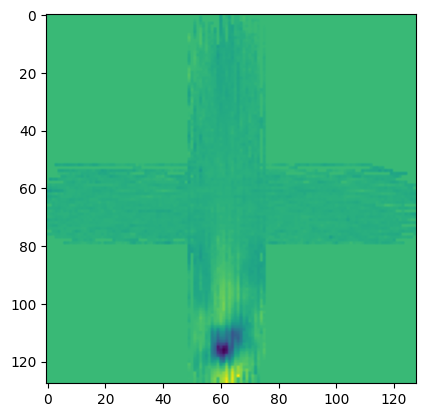

Name file:  b_aberr_3.fits


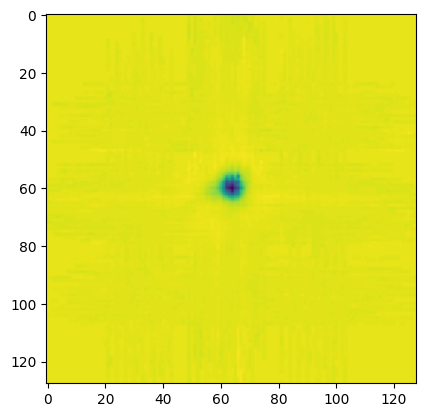

Name file:  b_aberr_4.fits


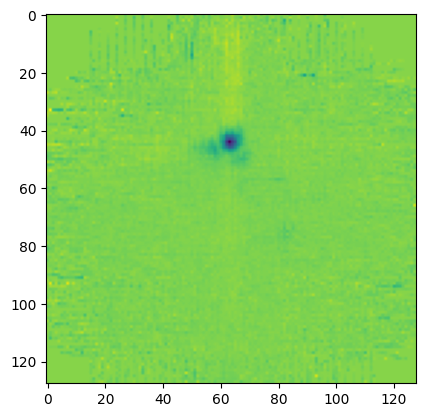

Name file:  b_aberr_5.fits


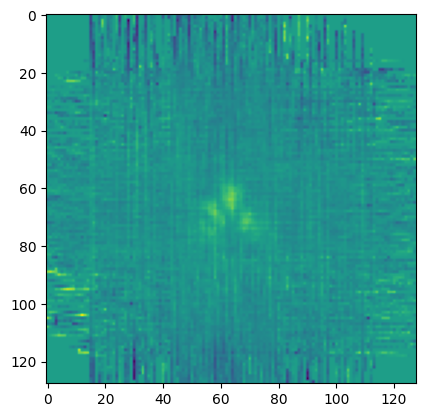

Name file:  b_aberr_6.fits


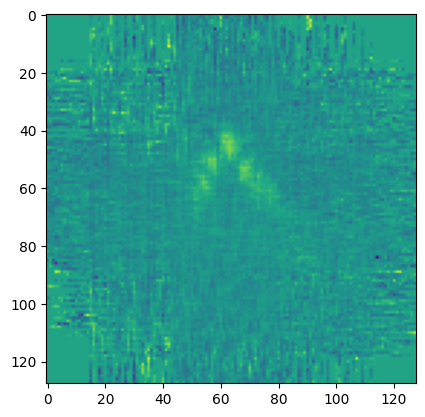

Name file:  b_aberr_7.fits


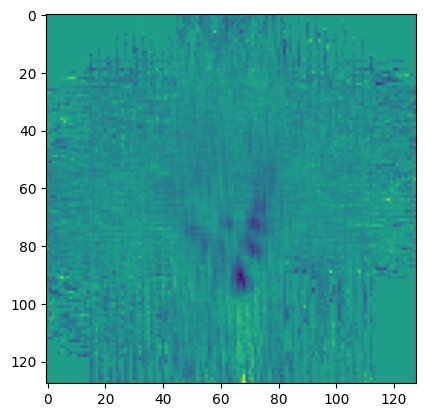

Name file:  b_aberr_1.fits


In [72]:
folder = '/Users/eleonora/Desktop/aberrationevol/'
files = os.listdir(folder)

maps = []
for filename in files: 
    if 'fits' in filename:
        hdul = fits.open(folder + filename) 
        mappa = hdul[1].data
        
        x, y = np.meshgrid(np.arange(0,np.shape(mappa)[1]), np.arange(0,np.shape(mappa)[0]))
        img_smooth = ndimage.gaussian_filter(mappa, sigma=(2, 2), order=0)
        peak = np.nanargmin(img_smooth)
        #peak = np.nanargmax(img_smooth)
        x0 = x.ravel()[peak] #x position of the brightest pixel
        y0 = y.ravel()[peak]
        
        positions = (x0, y0)
        r_min = 15
        r_max = 25
        annulus_aperture = CircularAnnulus(positions, r_in=r_min, r_out=r_max)
        aperstats = ApertureStats(mappa, annulus_aperture)
        std= aperstats.std #np.sqrt(aperstats.mean)

        mappa[mappa==np.nan]= std
        mappa = np.nan_to_num(mappa, nan=std)
        maps.append(mappa)
        plt.imshow(mappa)
        plt.show()
        
        fits_name = 'b_' + filename
        myfile = folder + fits_name
        print('Name file: ', fits_name)
        if os.path.isfile(myfile):
            os.remove(myfile)

        cards_list = []
        cards_list.append(fits.Card('ABERR'))
        hdr = fits.Header(cards=cards_list)
        prim_hdu0 = fits.PrimaryHDU(header=hdr)
        prim_hdu1 = fits.ImageHDU(data=mappa, name='FILT MAP')
        fits_hdu_list = fits.HDUList([prim_hdu0, prim_hdu1])
        fits_hdu_list.writeto(myfile, overwrite=True)